In [1]:
import pandas as pd

df = pd.read_csv(
    "data/credit_card_default_taiwan.csv",
    sep=";"
)

df.head()




,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [3]:
####Regression

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

import matplotlib.pyplot as plt


In [5]:
!python -m pip install pandas numpy scikit-learn matplotlib


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt

print("pandas:", pd.__version__)
print("sklearn:", sklearn.__version__)
df.columns


pandas: 2.3.3
sklearn: 1.8.0


Index(['Unnamed: 0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9',
       'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19',
       'X20', 'X21', 'X22', 'X23', 'Y'],
      dtype='object')

In [7]:
df = df.drop(columns=["Unnamed: 0"])



In [8]:
df["Y"] = pd.to_numeric(df["Y"], errors="coerce")


In [9]:
df = df.dropna(subset=["Y"])


In [10]:
df["Y"] = df["Y"].astype(int)


In [11]:
df["Y"].value_counts(normalize=True)


Y
0    0.7788
1    0.2212
Name: proportion, dtype: float64

In [12]:
X = df.drop(columns=["Y"])
y = df["Y"]


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [14]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

y_dummy_pred = dummy.predict(X_test)

print("Baseline (DummyClassifier)")
print(classification_report(y_test, y_dummy_pred))


Baseline (DummyClassifier)
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      4673
           1       0.00      0.00      0.00      1327

    accuracy                           0.78      6000
   macro avg       0.39      0.50      0.44      6000
weighted avg       0.61      0.78      0.68      6000



C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_c

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

pipe_lr.fit(X_train, y_train)

y_pred = pipe_lr.predict(X_test)
y_prob = pipe_lr.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


Logistic Regression
              precision    recall  f1-score   support

           0       0.87      0.70      0.77      4673
           1       0.37      0.62      0.46      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.68      0.70      6000

ROC-AUC: 0.7081149369197677


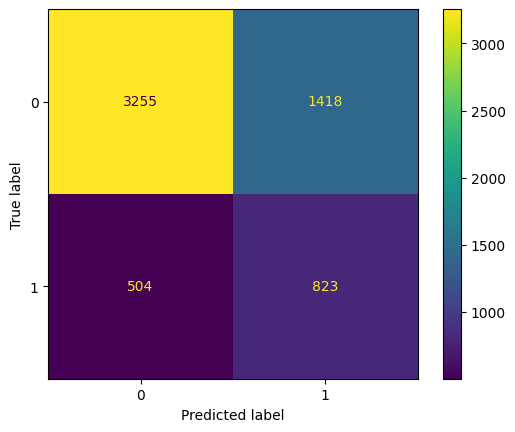

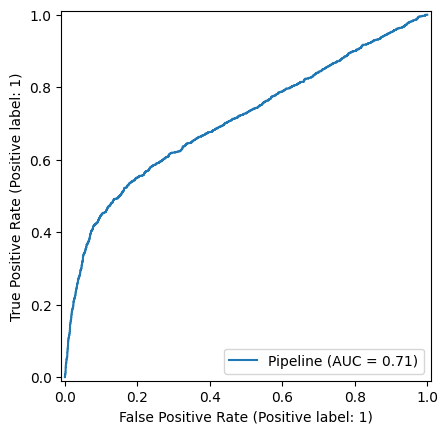

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(pipe_lr, X_test, y_test)
plt.show()

RocCurveDisplay.from_estimator(pipe_lr, X_test, y_test)
plt.show()


In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "lr__C": [0.01, 0.1, 1, 10],
    "lr__penalty": ["l2"],
    "lr__solver": ["lbfgs"]
}

gs = GridSearchCV(
    pipe_lr,
    param_grid,
    scoring="f1",   # default sınıfı önemli olduğu için
    cv=5,
    n_jobs=-1
)

gs.fit(X_train, y_train)

print("Best parameters:", gs.best_params_)


Best parameters: {'lr__C': 0.01, 'lr__penalty': 'l2', 'lr__solver': 'lbfgs'}


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [18]:
best_lr = gs.best_estimator_

y_pred_best = best_lr.predict(X_test)
y_prob_best = best_lr.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score

print("Tuned Logistic Regression")
print(classification_report(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_best))


Tuned Logistic Regression
              precision    recall  f1-score   support

           0       0.87      0.70      0.77      4673
           1       0.37      0.62      0.46      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.68      0.70      6000

ROC-AUC: 0.7075947042051284


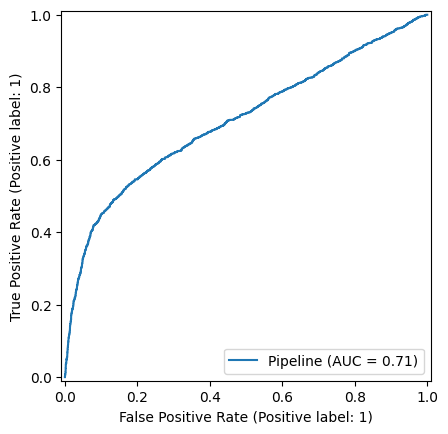

In [19]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(best_lr, X_test, y_test)
plt.show()


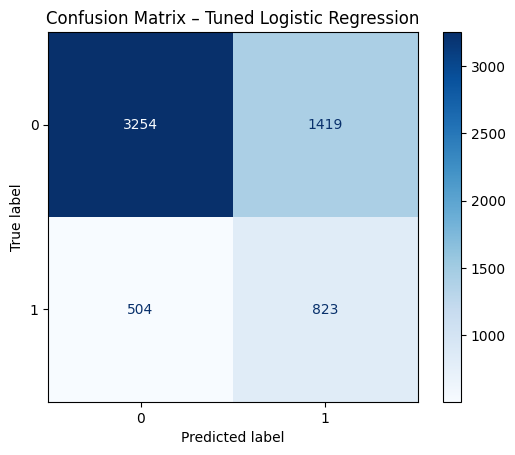

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    best_lr,
    X_test,
    y_test,
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix – Tuned Logistic Regression")
plt.show()


In [22]:
import numpy as np

y_prob = best_lr.predict_proba(X_test)[:, 1]
y_pred_thresh = (y_prob >= 0.4).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_thresh))


              precision    recall  f1-score   support

           0       0.87      0.42      0.57      4673
           1       0.28      0.78      0.41      1327

    accuracy                           0.50      6000
   macro avg       0.57      0.60      0.49      6000
weighted avg       0.74      0.50      0.53      6000



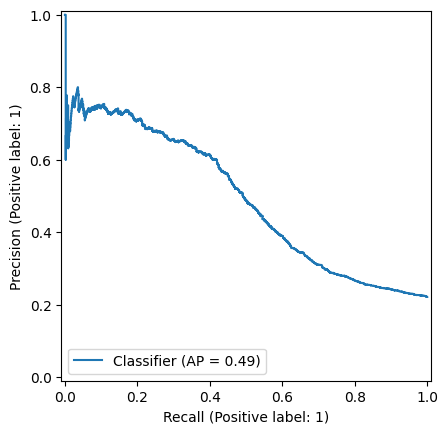

In [23]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

PrecisionRecallDisplay.from_predictions(y_test, y_prob)
plt.show()


In [24]:
from sklearn.metrics import confusion_matrix

cm_thresh = confusion_matrix(y_test, y_pred_thresh)
cm_thresh


array([[1964, 2709],
       [ 293, 1034]])

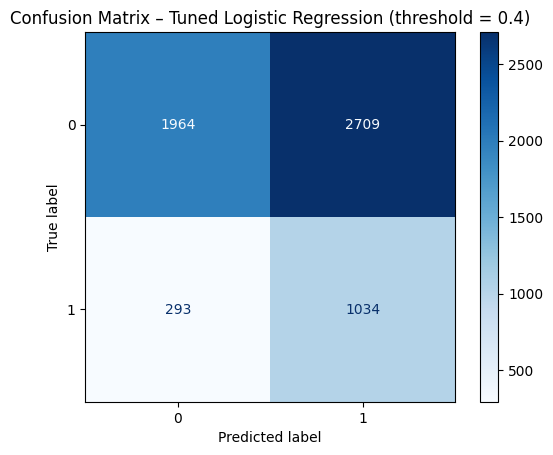

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_thresh,
    display_labels=[0, 1]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix – Tuned Logistic Regression (threshold = 0.4)")
plt.show()


In [27]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_prob = best_lr.predict_proba(X_test)[:, 1]

thresholds = [0.5, 0.4, 0.3, 0.2]

results = {}

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    report = classification_report(y_test, y_pred_t, output_dict=True)
    
    results[t] = {
        "TN": cm[0, 0],
        "FP": cm[0, 1],
        "FN": cm[1, 0],
        "TP": cm[1, 1],
        "precision_1": report["1"]["precision"],
        "recall_1": report["1"]["recall"],
        "f1_1": report["1"]["f1-score"]
    }


In [28]:
import pandas as pd

df_thresholds = pd.DataFrame(results).T
df_thresholds


,TN,FP,FN,TP,precision_1,recall_1,f1_1
0.5,3254.0,1419.0,504.0,823.0,0.367083,0.620196,0.461194
0.4,1964.0,2709.0,293.0,1034.0,0.276249,0.779201,0.407890
0.3,1012.0,3661.0,146.0,1181.0,0.243907,0.889977,0.382882
0.2,464.0,4209.0,66.0,1261.0,0.230530,0.950264,0.371046


In [29]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

# Olasılıklar (zaten eğitilmiş tuned model)
y_prob = best_lr.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.30, 0.65, 0.05)

results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    report = classification_report(y_test, y_pred_t, output_dict=True)

    results.append({
        "threshold": round(t, 2),
        "TN": cm[0, 0],
        "FP": cm[0, 1],
        "FN": cm[1, 0],
        "TP": cm[1, 1],
        "precision_1": report["1"]["precision"],
        "recall_1": report["1"]["recall"],
        "f1_1": report["1"]["f1-score"]
    })

df_thresholds = pd.DataFrame(results)
df_thresholds


,threshold,TN,FP,FN,TP,precision_1,recall_1,f1_1
0,0.30,1012,3661,146,1181,0.243907,0.889977,0.382882
1,0.35,1477,3196,228,1099,0.255879,0.828184,0.390964
2,0.40,1964,2709,293,1034,0.276249,0.779201,0.407890
3,0.45,2514,2159,385,942,0.303773,0.709872,0.425474
4,0.50,3254,1419,504,823,0.367083,0.620196,0.461194
5,0.55,3907,766,639,688,0.473177,0.518463,0.494786
6,0.60,4213,460,738,589,0.561487,0.443858,0.495791


In [2]:
####KNN

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])


In [31]:
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

k_values = [3, 5, 7, 11, 15, 25]
rows = []

for k in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    report = classification_report(y_test, y_pred, output_dict=True)
    
    rows.append({
        "k": k,
        "precision_1": report["1"]["precision"],
        "recall_1": report["1"]["recall"],
        "f1_1": report["1"]["f1-score"],
        "roc_auc": roc_auc_score(y_test, y_prob)
    })

df_knn_k = pd.DataFrame(rows)
df_knn_k


,k,precision_1,recall_1,f1_1,roc_auc
0,3,0.488000,0.367747,0.419424,0.677736
1,5,0.548724,0.356443,0.432161,0.701483
2,7,0.581957,0.345139,0.433302,0.709453
3,11,0.621514,0.352675,0.450000,0.724540
4,15,0.614743,0.333082,0.432063,0.732928
5,25,0.626087,0.325546,0.428359,0.743488


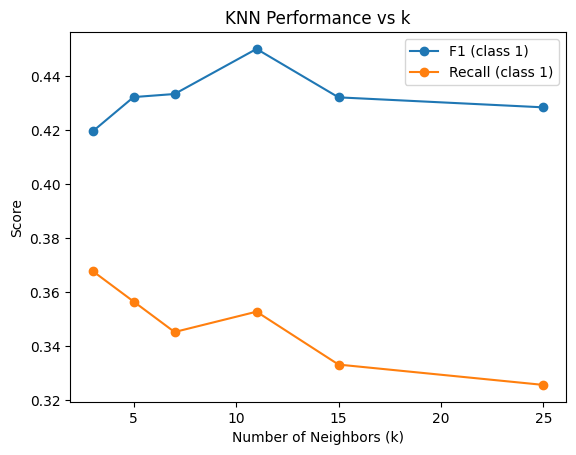

In [32]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df_knn_k["k"], df_knn_k["f1_1"], marker="o", label="F1 (class 1)")
plt.plot(df_knn_k["k"], df_knn_k["recall_1"], marker="o", label="Recall (class 1)")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Score")
plt.legend()
plt.title("KNN Performance vs k")
plt.show()


In [33]:
best_k = df_knn_k.sort_values("f1_1", ascending=False).iloc[0]["k"]
best_k


np.float64(11.0)

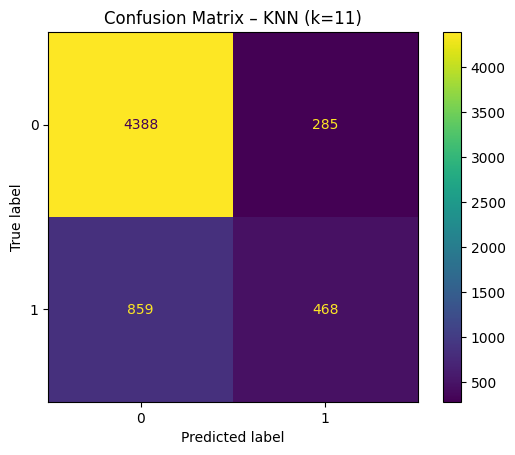

In [34]:
best_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=int(best_k)))
])

best_knn.fit(X_train, y_train)

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(best_knn, X_test, y_test, values_format="d")
plt.title(f"Confusion Matrix – KNN (k={int(best_k)})")
plt.show()


In [35]:
y_prob_knn = best_knn.predict_proba(X_test)[:, 1]

for t in [0.5, 0.4]:
    y_pred_t = (y_prob_knn >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, y_pred_t))



Threshold = 0.5
              precision    recall  f1-score   support

           0       0.84      0.94      0.88      4673
           1       0.62      0.35      0.45      1327

    accuracy                           0.81      6000
   macro avg       0.73      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000


Threshold = 0.4
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      4673
           1       0.55      0.42      0.48      1327

    accuracy                           0.80      6000
   macro avg       0.70      0.66      0.67      6000
weighted avg       0.78      0.80      0.78      6000



In [36]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

y_prob_knn = best_knn.predict_proba(X_test)[:, 1]


In [37]:
thresholds = np.arange(0.30, 0.65, 0.05)

results_knn = []

for t in thresholds:
    y_pred_t = (y_prob_knn >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    report = classification_report(y_test, y_pred_t, output_dict=True)

    results_knn.append({
        "threshold": round(t, 2),
        "TN": cm[0, 0],
        "FP": cm[0, 1],
        "FN": cm[1, 0],
        "TP": cm[1, 1],
        "precision_1": report["1"]["precision"],
        "recall_1": report["1"]["recall"],
        "f1_1": report["1"]["f1-score"]
    })

df_knn_thresholds = pd.DataFrame(results_knn)
df_knn_thresholds


,threshold,TN,FP,FN,TP,precision_1,recall_1,f1_1
0,0.30,3924,749,652,675,0.474017,0.508666,0.490731
1,0.35,3924,749,652,675,0.474017,0.508666,0.490731
2,0.40,4213,460,770,557,0.547689,0.419744,0.475256
3,0.45,4213,460,770,557,0.547689,0.419744,0.475256
4,0.50,4388,285,859,468,0.621514,0.352675,0.450000
5,0.55,4492,181,984,343,0.654580,0.258478,0.370610
6,0.60,4492,181,984,343,0.654580,0.258478,0.370610


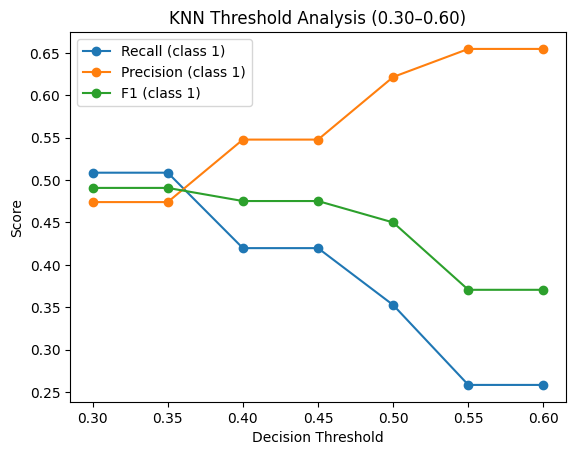

In [38]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df_knn_thresholds["threshold"], df_knn_thresholds["recall_1"], marker="o", label="Recall (class 1)")
plt.plot(df_knn_thresholds["threshold"], df_knn_thresholds["precision_1"], marker="o", label="Precision (class 1)")
plt.plot(df_knn_thresholds["threshold"], df_knn_thresholds["f1_1"], marker="o", label="F1 (class 1)")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.legend()
plt.title("KNN Threshold Analysis (0.30–0.60)")
plt.show()


In [39]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# KNN olasılıkları
y_prob_knn = best_knn.predict_proba(X_test)[:, 1]

# Threshold = 0.5
threshold = 0.5
y_pred_knn_05 = (y_prob_knn >= threshold).astype(int)


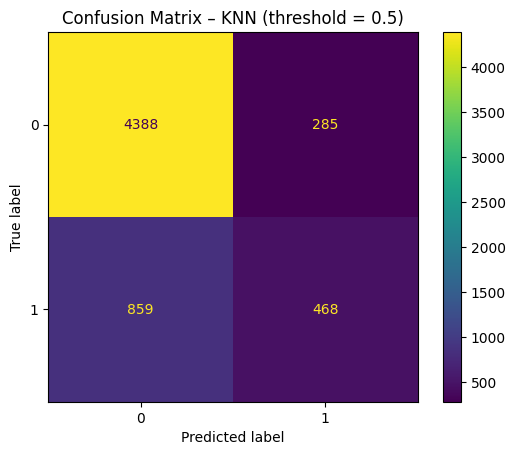

In [40]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_knn_05,
    values_format="d"
)
plt.title("Confusion Matrix – KNN (threshold = 0.5)")
plt.show()


In [21]:
import pandas as pd 

df = pd.read_csv("data/credit_card_default_taiwan.csv",sep = ";", header = 1)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [5]:
print(df.shape)
print(df.columns)

(30000, 25)
Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')


In [6]:
df = df.drop(columns=["ID"])

df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [7]:
y = df["default payment next month"]
y.head()

0    1
1    1
2    0
3    0
4    0
Name: default payment next month, dtype: int64

In [8]:
X = df.drop(columns=["default payment next month"])
X.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


In [9]:
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (30000, 23)
y shape: (30000,)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [11]:
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))



Train shape: (24000, 23) (24000,)
Test shape: (6000, 23) (6000,)
default payment next month
0    0.778792
1    0.221208
Name: proportion, dtype: float64
default payment next month
0    0.778833
1    0.221167
Name: proportion, dtype: float64


In [12]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred_baseline))
print("Baseline F1 Score:", f1_score(y_test, y_pred_baseline))


Baseline Accuracy: 0.7788333333333334
Baseline F1 Score: 0.0


In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators = 200,
    random_state = 42,
    class_weight = "balanced"
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]


In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))


Accuracy: 0.8148333333333333
Precision: 0.6529745042492918
Recall: 0.3474001507159005
F1 Score: 0.4535169699950812
ROC-AUC: 0.7563224159181535


In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)
cm


array([[4428,  245],
       [ 866,  461]], dtype=int64)

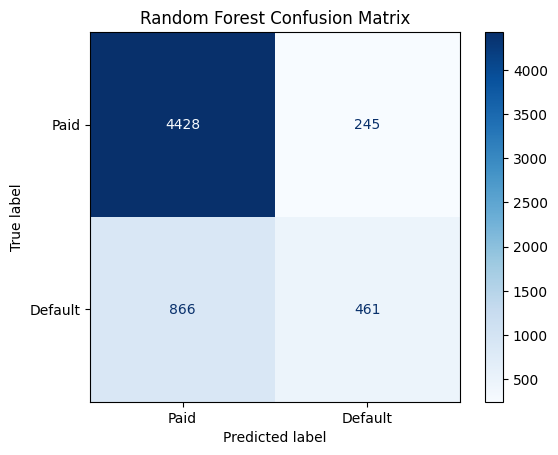

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["Paid", "Default"],
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()


In [33]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}


In [34]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)


In [35]:
grid.fit(X_train, y_train)


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [36]:
grid.best_params_

In [38]:
best_rf = grid.best_estimator_

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred_best = best_rf.predict(X_test)
y_proba_best = best_rf.predict_proba(X_test)[:, 1]

print("Tuned RF Accuracy:", accuracy_score(y_test, y_pred_best))
print("Tuned RF Precision:", precision_score(y_test, y_pred_best))
print("Tuned RF Recall:", recall_score(y_test, y_pred_best))
print("Tuned RF F1:", f1_score(y_test, y_pred_best))
print("Tuned RF ROC-AUC:", roc_auc_score(y_test, y_proba_best))


Tuned RF Accuracy: 0.7878333333333334
Tuned RF Precision: 0.518595041322314
Tuned RF Recall: 0.5674453654860587
Tuned RF F1: 0.541921554516013
Tuned RF ROC-AUC: 0.7733571345982009


In [39]:
y_proba_best = best_rf.predict_proba(X_test)[:, 1]


In [40]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.3, 0.61, 0.05)

for t in thresholds:
    y_pred_thresh = (y_proba_best >= t).astype(int)
    p = precision_score(y_test, y_pred_thresh)
    r = recall_score(y_test, y_pred_thresh)
    f = f1_score(y_test, y_pred_thresh)
    print(f"Threshold={t:.2f} | Precision={p:.3f} | Recall={r:.3f} | F1={f:.3f}")


Threshold=0.30 | Precision=0.305 | Recall=0.860 | F1=0.450
Threshold=0.35 | Precision=0.348 | Recall=0.787 | F1=0.482
Threshold=0.40 | Precision=0.410 | Recall=0.690 | F1=0.514
Threshold=0.45 | Precision=0.463 | Recall=0.605 | F1=0.525
Threshold=0.50 | Precision=0.519 | Recall=0.567 | F1=0.542
Threshold=0.55 | Precision=0.552 | Recall=0.508 | F1=0.529
Threshold=0.60 | Precision=0.582 | Recall=0.462 | F1=0.515


In [41]:
final_threshold = 0.50

y_proba_final = best_rf.predict_proba(X_test)[:, 1]
y_pred_final = (y_proba_final >= final_threshold).astype(int)


In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("FINAL MODEL RESULTS (Threshold = 0.50)")
print("--------------------------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall   :", recall_score(y_test, y_pred_final))
print("F1 Score :", f1_score(y_test, y_pred_final))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_final))


FINAL MODEL RESULTS (Threshold = 0.50)
--------------------------------------
Accuracy : 0.7878333333333334
Precision: 0.518595041322314
Recall   : 0.5674453654860587
F1 Score : 0.541921554516013
ROC-AUC  : 0.7733571345982009


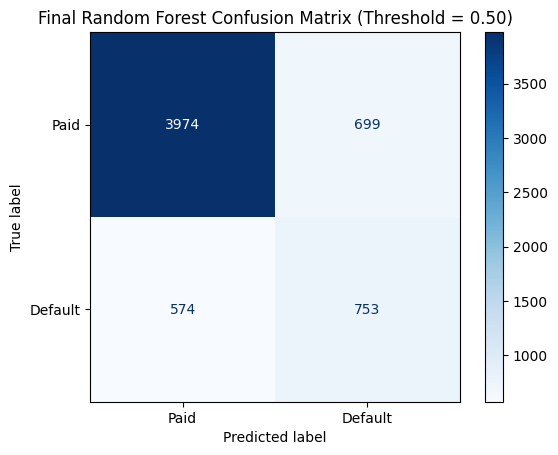

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final,
    display_labels=["Paid", "Default"],
    cmap="Blues"
)

plt.title("Final Random Forest Confusion Matrix (Threshold = 0.50)")
plt.show()
